# <center><span style="color:#336699">Introdução à Programação com Dados Geoespaciais em Ambientes de Computação Interativa</span></center>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 150%;">
    Aula 03: Manipulação de Dados Matriciais em Python</br>
    <span style="font-size: 0.75em;">Parte II - Processamento de imagens usando NumPy e Visualização com Matplotlib</span>
</div>

<br/>

<div style="text-align: center;font-size: 90%;">
    Thales Sehn Körting<sup><a href="https://orcid.org/0000-0002-0876-0501"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Gilberto Ribeiro de Queiroz<sup><a href="https://orcid.org/0000-0001-7534-0219"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Karine Reis Ferreira<sup><a href="https://orcid.org/0000-0003-2656-5504"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Marcos Adami<sup><a href="https://orcid.org/0000-0003-4247-4477"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>
    <br/><br/>
    Divisão de Observação da Terra e Geoinformática, Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Última Atualização: 17 de Março de 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
    <b>Resumo.</b> Este Jupyter Notebook apresenta um resumo de operações aritméticas aplicadas ao processamento de imagens com a biblioteca <em>NumPy</em>, e a visualização dos resultados com a biblioteca <em>Matplotlib</em>. A aplicação das bibliotecas se dá na visualização de uma imagem com 4 bandas espectrais, o cálculo de índices espectrais (no exemplo índice de vegetação e índice de água) e aplicação de limiar para classificação preliminar.
</div>

# <span style="color:#336699">Importação das bibliotecas necessárias</span>
<hr style="border:1px solid #0077b9;">

Os comandos abaixo importam bibliotecas, sendo *rasterio* (geralmente utilizada como *rio* nos scripts, para simplificar), *NumPy* (geralmente chamada *np*) e o módulo *Pyplot* da *Matplotlib* (geralmente chamada *plt*):

In [1]:
import rasterio as rio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

Para verificar as versões das bibliotecas em uso:

In [2]:
print(rio.__version__)
print(np.__version__)
print(matplotlib.__version__)

1.4.3
1.26.4
3.8.4


# <span style="color:#336699">Leitura de Arquivos GeoTIFF para manipulação das matrizes</span>
<hr style="border:1px solid #0077b9;">

**Exemplo 1.** Abrir os arquivos GeoTIFF de 3 bandas de uma cena, calcular e visualizar dois índices espectrais bem conhecidos:
- *Normalized Difference Water Index* (NDWI)
  
$NDWI = \frac{Green - NIR}{Green + NIR}$

- *Normalized Difference Vegetation Index* (NDVI)
  
$NDVI = \frac{NIR - Red}{NIR + Red}$

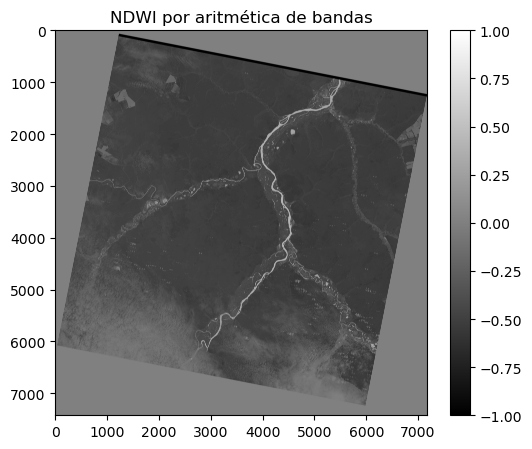

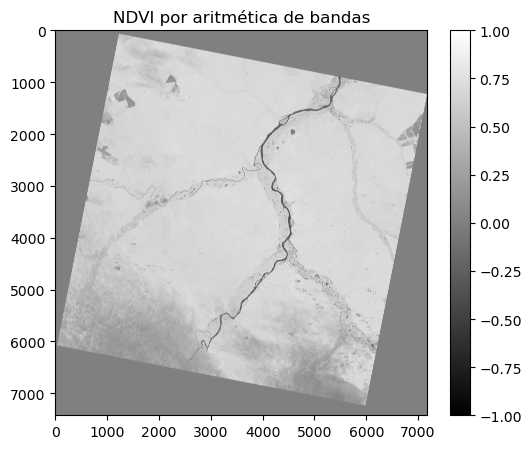

In [3]:
with rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND5.tif', 'r') as dataset_blue, \
     rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND6.tif', 'r') as dataset_green, \
     rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND7.tif', 'r') as dataset_red, \
     rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND8.tif', 'r') as dataset_nir:
    # lembre-se que o tipo de dado era uint8
    # isso significa que os dados são sem sinal (u)
    # e o tipo inteiro de 8 bits (int8, somente entre 0 e 255)
    # por isso é preciso trocar o tipo de dados para o cálculo do NDVI funcionar
    matriz_blue = dataset_blue.read(1).astype(np.float32)
    matriz_green = dataset_green.read(1).astype(np.float32)
    matriz_red = dataset_red.read(1).astype(np.float32)
    matriz_nir = dataset_nir.read(1).astype(np.float32)

    # estamos colocando o valor 0.0001 nos denominadores
    # somente para evitar possíveis divisões por zero
    ndwi = (matriz_green - matriz_nir) / (matriz_green + matriz_nir + 0.0001)
    ndvi = (matriz_nir - matriz_red) / (matriz_nir + matriz_red + 0.0001)

    plt.figure(figsize=(6, 5))
    plt.title("NDWI por aritmética de bandas")
    plt.imshow(ndwi, cmap='gray', vmin=-1, vmax=1)
    plt.colorbar()

    plt.figure(figsize=(6, 5))
    plt.title("NDVI por aritmética de bandas")
    plt.imshow(ndvi, cmap='gray', vmin=-1, vmax=1)
    plt.colorbar()
         
    plt.show()

----

**Exemplo 2.** Visualizar uma composição colorida em falsa cor, representando os canais RGB com as informações das matrizes das bandas verde, infra-vermelho e vermelho:

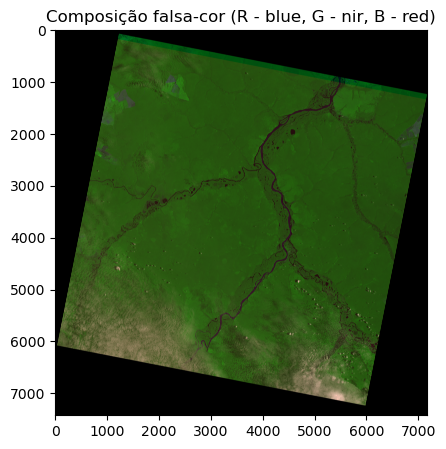

In [4]:
# definimos os números de linhas/colunas
# a partir de alguma matriz da imagem original
linhas = matriz_green.shape[0]
colunas = matriz_green.shape[1]

# para criar uma visualização em falsa cor, podemos associar as bandas
# do Green, Red e NIR nos canais disponíveis do comando imshow (RGB)
# para isso criamos uma matriz com 3 dimensões
# (linhas x colunas x 3 bandas)
array_rgb = np.zeros((linhas, colunas, 3))

# veja que, para visualizar corretamente,
# precisaremos dividir as matrizes pelo
# maior valor, para obtermos uma matriz
# com valores normalizados entre 0.0 e 1.0
array_rgb[:, :, 0] = matriz_blue / 255 # canal de visualização Red
array_rgb[:, :, 1] = matriz_nir / 255  # canal de visualização Green
array_rgb[:, :, 2] = matriz_red / 255  # canal de visualização Blue

plt.figure(figsize=(5, 5))
plt.imshow(array_rgb)
plt.title('Composição falsa-cor (R - blue, G - nir, B - red)');

----

**Exemplo 3.** Realizar um fatiamento nos índices espectrais, para ressaltar alvos de vegetação ou água. Inicialmente pode-se visualizar os histogramas para compreender algumas propriedades estatísticas da imagem:

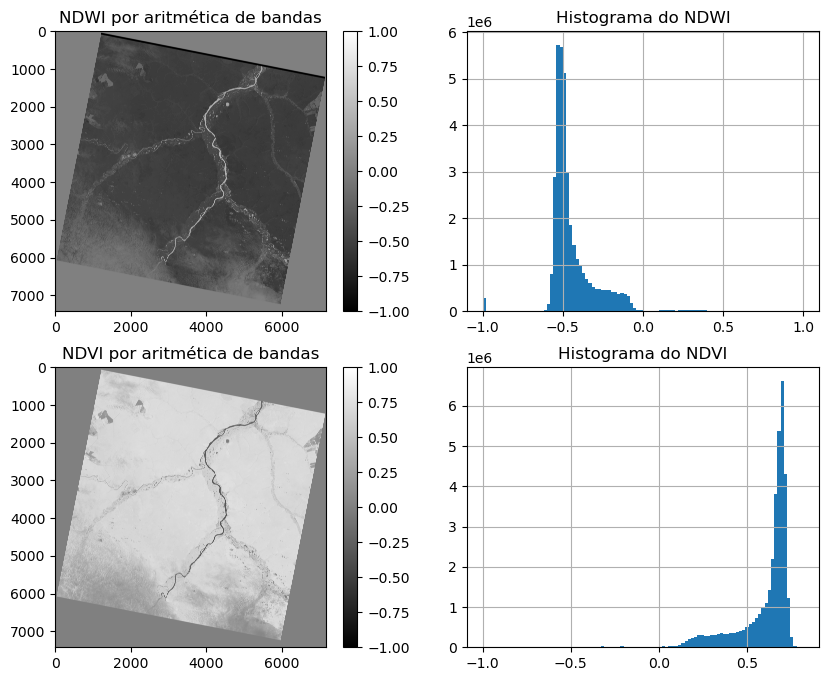

In [5]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(ndwi, cmap='gray', vmin=-1, vmax=1), plt.colorbar(), plt.title("NDWI por aritmética de bandas")
plt.subplot(2, 2, 2)
plt.hist(ndwi[ndwi != 0].flatten(), bins=100), plt.grid(), plt.title('Histograma do NDWI')
plt.subplot(2, 2, 3)
plt.imshow(ndvi, cmap='gray', vmin=-1, vmax=1), plt.colorbar(), plt.title("NDVI por aritmética de bandas")
plt.subplot(2, 2, 4)
plt.hist(ndvi[ndvi != 0].flatten(), bins=100), plt.grid(), plt.title('Histograma do NDVI');

Com base nos histogramas, pode-se estimar limiares para dividir as distribuições entre alvos com NDWI positivo (indicando presença de água), ou com NDVI muito alto (indicando presença de vegetação):

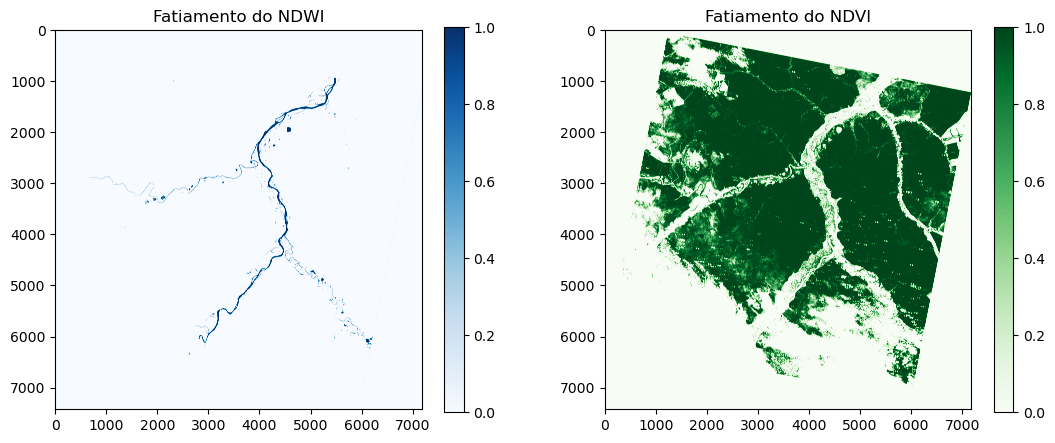

In [13]:
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
# usando o limiar usual sobre o índice de água (ndwi > 0)
plt.imshow(ndwi > 0, cmap='Blues'), plt.title('Fatiamento do NDWI'), plt.colorbar()
# usando o limiar 0.65 sobre o índice de vegetação
plt.subplot(1, 2, 2)
plt.imshow(ndvi > 0.65, cmap='Greens'), plt.title('Fatiamento do NDVI'), plt.colorbar();

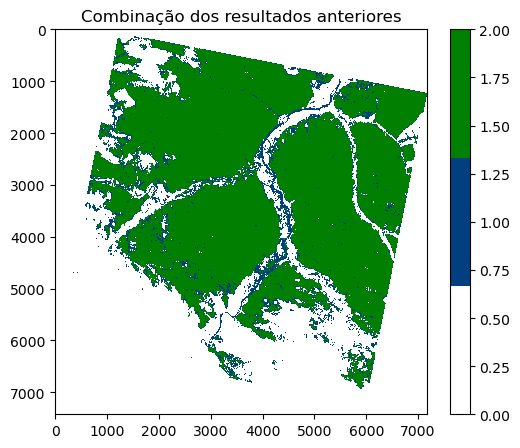

In [15]:
# podemos criar uma cópia da matriz ndwi, porém 
# substituindo os valores originais por 0
combinacao = np.zeros_like(ndwi)
# aplicamos a mesma regra anterior para fazer uma
# classificação simples sobre os dados, sendo
# 0 para fundo, 1 para água e 2 para vegetação
combinacao[ndwi > 0] = 1
combinacao[ndvi > 0.65] = 2

plt.figure(figsize=(6, 5))
plt.title('Combinação dos resultados anteriores')
colormap_3classes = plt.get_cmap('ocean_r', 3)
plt.imshow(combinacao, cmap=colormap_3classes)
plt.colorbar();              

----

**Exemplo 4.** Abrir um recorte da mesma imagem anterior, porém num arquivo contendo todas as bandas integradas. Pode-se aplicar um contraste nas bandas R, G e B para melhorar a visualização em *true color*:

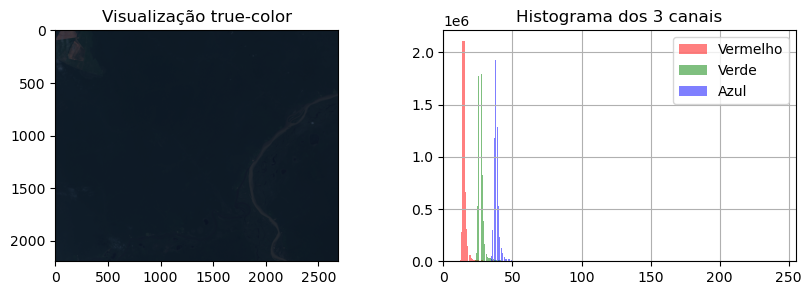

In [8]:
# o comando abaixo abre a imagem armazenada no mesmo ambiente
# em que o script será executado
# with rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_bgrnir_clip.tif', 'r') as dataset_bgrnir:
# entretanto, podemos usar um link para um arquivo GeoTIFF 
# ao invés de um caminho para um arquivo local
with rio.open('https://github.com/tkorting/remote-sensing-images/raw/refs/heads/master/CBERS_4A_MUX_20260205_214_127_L4_bgrnir_clip.tif', 'r') as dataset_bgrnir:
    # lembre-se que o tipo de dado era uint8
    # isso significa que os dados são sem sinal (u)
    # e o tipo inteiro de 8 bits (int8, somente entre 0 e 255)
    # como agora as 3 bandas estão no mesmo arquivo, podemos usar
    # a função read(N), onde N é o número da banda desejada
    # nesse caso, a imagem está organizada como
    # banda 1 Blue, banda 2 Green, banda 3 Red, banda 4 NIR
    matriz_blue = dataset_bgrnir.read(1).astype(np.float32)
    matriz_green = dataset_bgrnir.read(2).astype(np.float32)
    matriz_red = dataset_bgrnir.read(3).astype(np.float32)

    # definimos os números de linhas/colunas
    # a partir de alguma matriz da imagem original
    linhas = matriz_blue.shape[0]
    colunas = matriz_blue.shape[1]
    
    # por isso criamos uma matriz com 3 dimensões
    # (linhas x colunas x 3 bandas)
    array_rgb = np.zeros((linhas, colunas, 3))    
    array_rgb[:, :, 0] = matriz_red / 255
    array_rgb[:, :, 1] = matriz_green / 255
    array_rgb[:, :, 2] = matriz_blue / 255

    # pode-se visualizar o histograma das 3 bandas para 
    # pensar numa estratégia de contraste baseada nos
    # limites mínimos e máximos encontrados em cada banda
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(array_rgb), plt.title('Visualização true-color');
    plt.subplot(1, 2, 2)
    plt.hist(matriz_red[matriz_red != 0].flatten(), bins=100, label='Vermelho', color='red', alpha=0.5)
    plt.hist(matriz_green[matriz_green != 0].flatten(), bins=100, label='Verde', color='green', alpha=0.5)
    plt.hist(matriz_blue[matriz_blue != 0].flatten(), bins=100, label='Azul', color='blue', alpha=0.5)
    plt.title('Histograma dos 3 canais'), plt.grid(), plt.legend(), plt.xlim([0, 255])

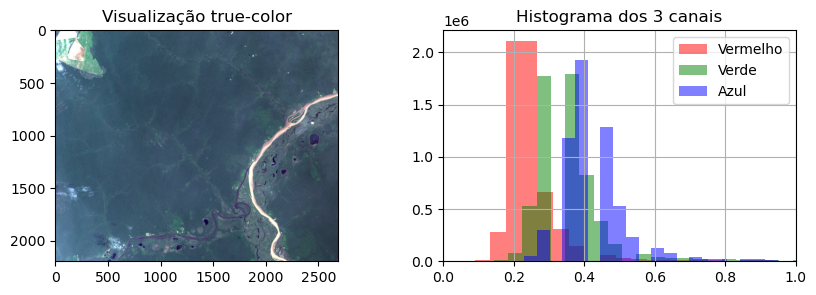

In [9]:
# ao observar os limites mínimos e máximos dos 3 histogramas
# podemos notar que os 3 canais tem valores mínimos em torno
# de 10, 20 e 30 e valores máximos em torno de 40, 50 e 60
# podemos usar esses intervalos para melhorar a visualização
array_rgb = np.zeros((linhas, colunas, 3))    
array_rgb[:, :, 0] = (matriz_red - 10) / 20
array_rgb[:, :, 1] = (matriz_green - 20) / 20
array_rgb[:, :, 2] = (matriz_blue - 30) / 20

# para garantir que todos os valores estejam
# entre 0.0 e 1.0 (para fins de visualização)
array_rgb = np.clip(array_rgb, a_min=0.0, a_max=1.0)

# esses vetores são cópias dos valores originais
# criados apenas para visualizar o histograma dos 3 canais
matriz_red_01 = (matriz_red[matriz_red != 0] - 10) / 20
matriz_green_01 = (matriz_green[matriz_green != 0] - 20) / 20
matriz_blue_01 = (matriz_blue[matriz_blue != 0] - 30) / 20

# pode-se visualizar o histograma das 3 bandas para 
# pensar numa estratégia de contraste baseado nos
# limites mínimos e máximos encontrados em cada banda
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(array_rgb), plt.title('Visualização true-color');
plt.subplot(1, 2, 2)
plt.hist(matriz_red_01, bins=100, label='Vermelho', color='red', alpha=0.5)
plt.hist(matriz_green_01, bins=100, label='Verde', color='green', alpha=0.5)
plt.hist(matriz_blue_01, bins=100, label='Azul', color='blue', alpha=0.5)
plt.title('Histograma dos 3 canais'), plt.grid(), plt.legend(), plt.xlim([0, 1]);

# opcional: salvar o gráfico em um arquivo png
plt.savefig('visualizacao_mais_histograma.png', dpi=100)

----

**Exemplo 5.** Salvar um arquivo GeoTIFF com os 2 índices espectrais calculados anteriormente. Para isso, pode-se usar a imagem de referência (qualquer uma das bandas) para obter a maior parte dos metadados necessários para gerar o GeoTIFF de forma correta:

In [10]:
# podemos abrir as 3 bandas necessárias para o cálculo dos índices NDWI e NDVI
with rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND6.tif', 'r') as dataset_green, \
     rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND7.tif', 'r') as dataset_red, \
     rio.open('../dados/raster/CBERS_4A_MUX_20260205_214_127_L4_BAND8.tif', 'r') as dataset_nir:
    # leitura das 3 matrizes e conversão para o tipo 
    # adequado ao cálculo de divisão
    matriz_green = dataset_green.read(1).astype(np.float32)
    matriz_red = dataset_red.read(1).astype(np.float32)
    matriz_nir = dataset_nir.read(1).astype(np.float32)

    # estamos colocando o valor 0.0001 nos denominadores
    # somente para evitar possíveis divisões por zero
    ndwi = (matriz_green - matriz_nir) / (matriz_green + matriz_nir + 0.0001)
    ndvi = (matriz_nir - matriz_red) / (matriz_nir + matriz_red + 0.0001)

    # fazer uma cópia dos metadados do dataset green
    # para ser usado como referência, alterando
    # as partes necessárias (tipo de dado e número de bandas)
    reference_metadata = dataset_green.meta.copy()
    reference_metadata['dtype'] = 'float32'
    reference_metadata['count'] = 2

    # agora a biblioteca pode abrir a imagem no modo de gravação
    # 'w' (write) para salvar as 2 matrizes num novo arquivo
    with rio.open('CBERS_4A_MUX_20260205_NDWI_and_NDVI.tif', 'w', **reference_metadata) as dataset_output:
        # o comando write escreve no arquivo a matriz 
        # informada na banda correspondente, nesse caso 
        # banda 1 ndwi, banda 2 ndvi
        dataset_output.write(ndwi, 1)
        dataset_output.write(ndvi, 2)
    

# <span style="color:#336699">Comentários gerais</span>
<hr style="border:1px solid #0077b9;">

- Em diversos casos, a aplicação de limiares sobre índices espectrais produz rapidamente resultados de mapeamento preliminar de alvos.
- A combinação das bibliotecas GDAL, NumPy e Matplotlib permite a criação de muitas ferramentas de análise de imagens.

# <span style="color:#336699">Referências Bibliográficas</span>
<hr style="border:1px solid #0077b9;">

- John R. Jensen. Sensoriamento remoto da vegetação. In Keith C. Clarke, editor, Sensoriamento Remoto do Ambiente. Parêntese Editora, São José dos Campos, São Paulo, Brasil, 2009.